In [8]:
import pandas as pd
import seaborn as sns

In [9]:
df = pd.read_csv('personal_carbon_footprint_behavior.csv')
df

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
0,1,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,11.03,High
1,1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,7.44,Medium
2,1,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,6.01,Medium
3,1,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,12.70,High
4,1,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,6.33,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...
1395,200,Weekend,Bike,7.73,4.12,25,Veg,2.8,0.58,1,4.83,Low
1396,200,Weekend,Walk,5.20,4.72,75,Non-Veg,7.1,0.56,1,6.74,Medium
1397,200,Weekday,Bike,7.16,3.88,25,Non-Veg,3.2,0.72,2,7.95,Medium
1398,200,Weekday,Bus,10.91,3.84,75,Mixed,4.7,0.77,0,6.08,Medium


In [10]:
df[['user_id', 'carbon_footprint_kg']].groupby(['user_id']).mean()

,carbon_footprint_kg
user_id,
1,7.700000
2,9.375714
3,8.977143
4,6.714286
5,8.367143
...,...
196,8.561429
197,9.305714
198,6.702857


In [11]:
df[['day_type', 'carbon_footprint_kg']].groupby(['day_type']).mean()

,carbon_footprint_kg
day_type,
Weekday,8.102497
Weekend,7.850412


In [12]:
df.dtypes

user_id                  int64
day_type                   str
transport_mode             str
distance_km            float64
electricity_kwh        float64
renewable_usage_pct      int64
food_type                  str
screen_time_hours      float64
waste_generated_kg     float64
eco_actions              int64
carbon_footprint_kg    float64
carbon_impact_level        str
dtype: object

In [13]:
df.shape

(1400, 12)

<Axes: >

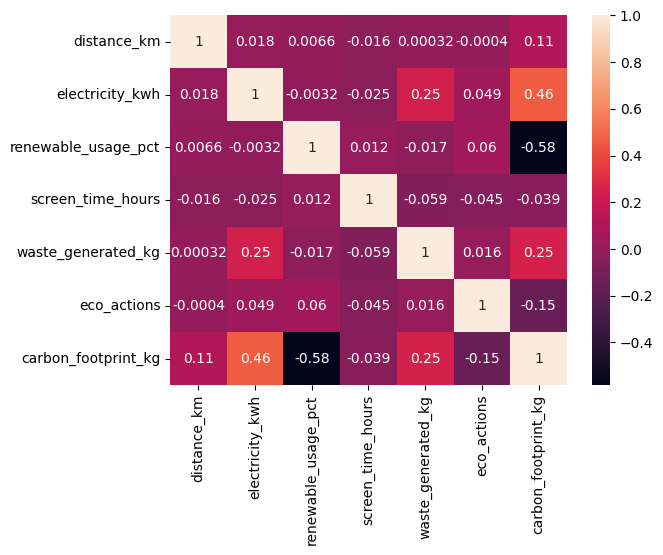

In [14]:
sns.heatmap(
    df[
        ["distance_km", "electricity_kwh", "renewable_usage_pct",
         "screen_time_hours", "waste_generated_kg", "eco_actions",
         "carbon_footprint_kg"]
    ].corr(), annot=True)

In [15]:
avg_by_user = df.groupby('user_id')['carbon_footprint_kg'].mean().sort_values(ascending=False).reset_index()
avg_by_user.columns = ['user_id', 'avg_carbon_footprint_kg']
avg_by_user

,user_id,avg_carbon_footprint_kg
0,14,11.387143
1,74,10.950000
2,125,10.834286
3,25,10.551429
4,30,10.370000
...,...,...
195,200,5.960000
196,139,5.884286
197,61,5.632857
198,156,5.392857


In [16]:
df.groupby('day_type')['carbon_footprint_kg'].agg(['mean', 'count'])

,mean,count
day_type,,
Weekday,8.102497,721
Weekend,7.850412,679


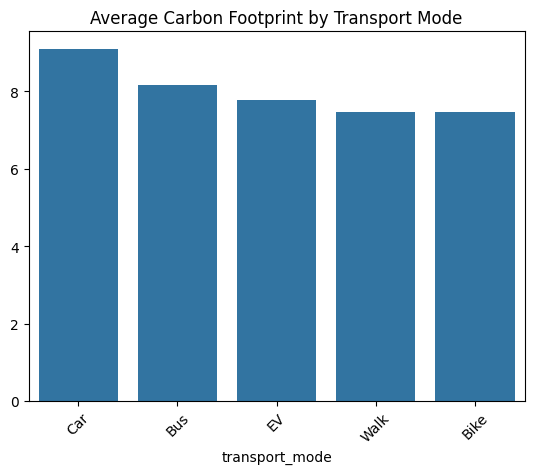

In [17]:
import matplotlib.pyplot as plt
avg_by_transport = df.groupby('transport_mode')['carbon_footprint_kg'].mean().sort_values(ascending=False)
sns.barplot(x=avg_by_transport.index, y=avg_by_transport.values)
plt.title('Average Carbon Footprint by Transport Mode')
plt.xticks(rotation=45)
plt.show()